# Study 11 — What if ability changes gradually rather than all at once?

Studies 07–10 assumed that a player's underlying frame-win probability changed abruptly from 58% to 64%.

That was useful because it made the behaviour of different estimators easy to see. But it is also artificial. Real playing ability is unlikely to jump permanently from one level to another between two consecutive frames.

This study changes **one thing only**: the underlying ability path.

Instead of an instantaneous jump, we will assume:

- the first 1,000 frames are played at a true frame-win probability of 58%;
- ability then rises **linearly from 58% to 64% over 250 frames**;
- after that, true ability remains at 64%.

The 250-frame transition is a deliberately simple illustrative choice. It is not estimated or optimised, and we will not compare alternative transition lengths or shapes.

Everything else remains controlled. Frames are still independent conditional on the current true probability, there is no momentum or parameter uncertainty, and we will use the estimator framework already established in the preceding studies.

The question is:

> **What happens to our estimates when the thing we are trying to measure changes gradually rather than jumping between fixed levels?**

This lets us separate two ideas that are easy to blur together:

1. an estimator can be slow because it remembers older observations;
2. the underlying quantity itself can be moving while we are trying to estimate it.

The aim is not to identify the best estimator. It is to understand what gradual change does to the estimation problem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Keep the study reproducible when we later simulate individual careers.
rng = np.random.default_rng(42)

# Carry forward the same ability levels used in Studies 07–10.
p_start = 0.58
p_end = 0.64

pre_change_frames = 1_000
transition_frames = 250

## Build the gradual ability path

The previous studies used a sudden change: one frame was played at 58%, and the next at 64%.

Here we replace that cliff with a simple **linear transition**.

A linear transition means the true frame-win probability increases by the same amount from one transition frame to the next. Over 250 frames it will move smoothly from 58% to 64%.

This is not intended as a realistic model of how a particular player's ability develops. It is a controlled way to remove the instantaneous jump while introducing no other complication.

After the transition finishes, ability will remain fixed at 64%.

In [2]:
# Exclude 58% itself so frame 1,001 is already the first improving frame,
# while the 250th transition frame reaches exactly 64%.
transition_p = np.linspace(
    p_start,
    p_end,
    transition_frames + 1
)[1:]

transition_p[:5], transition_p[-5:]

(array([0.58024, 0.58048, 0.58072, 0.58096, 0.5812 ]),
 array([0.63904, 0.63928, 0.63952, 0.63976, 0.64   ]))

In [3]:
# Keep 500 frames after the transition so we can see how the estimators
# behave once true ability has stopped changing.
post_transition_frames = 500

true_p = np.concatenate([
    np.full(pre_change_frames, p_start),
    transition_p,
    np.full(post_transition_frames, p_end),
])

len(true_p)

1750

In [4]:
check_frames = [1, 1000, 1001, 1050, 1100, 1250, 1251, 1750]

path_check = pd.DataFrame({
    "frame": check_frames,
    "true_p": [true_p[frame - 1] for frame in check_frames],
})

path_check

,frame,true_p
0,1,0.58000
1,1000,0.58000
2,1001,0.58024
3,1050,0.59200
4,1100,0.60400
5,1250,0.64000
6,1251,0.64000
7,1750,0.64000


## A moving target

This changes the estimation problem in an important way.

With the abrupt change used previously, there were two fixed regimes: old observations came from a 58% player and new observations came from a 64% player. Once enough new evidence accumulated, an estimator could eventually settle around the new fixed level.

During the transition here, there is temporarily no fixed level to recover.

The player's true probability is changing while observations are being collected. Any estimator that uses past frames therefore combines evidence generated at slightly different underlying ability levels.

This creates a form of **lag**: even a perfectly well-behaved estimator may sit below the player's current ability while that ability is rising, because part of its evidence necessarily comes from earlier, weaker states.

Before adding sampling noise, we will first examine this underlying probability path directly.

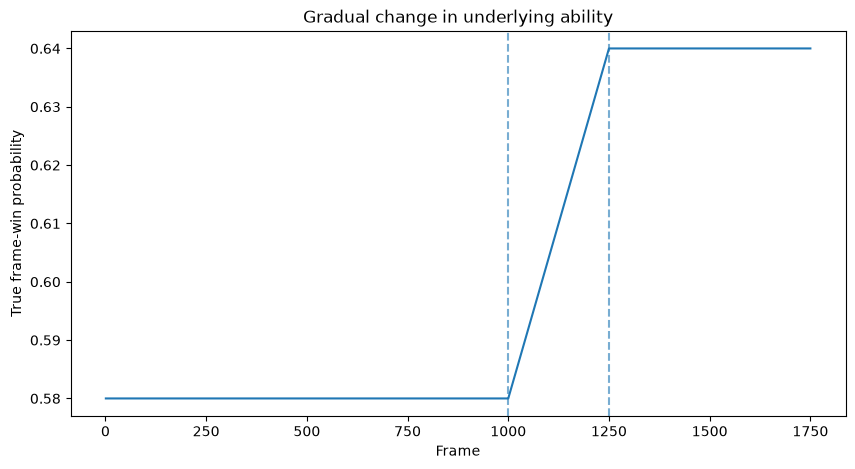

In [5]:
frames = np.arange(1, len(true_p) + 1)

plt.figure(figsize=(10, 5))
plt.plot(frames, true_p)

plt.axvline(1000, linestyle="--", alpha=0.6)
plt.axvline(1250, linestyle="--", alpha=0.6)

plt.xlabel("Frame")
plt.ylabel("True frame-win probability")
plt.title("Gradual change in underlying ability")

plt.show()

## How much lag is built into the estimators?

Before simulating any wins and losses, we can apply the estimators directly to the true probability path.

This removes sampling noise completely.

The resulting paths show the **expected response** of each estimator to gradual change:

- the 250-frame rolling estimator averages the most recent 250 true probabilities;
- the exponentially weighted estimator gives greater weight to recent probabilities and progressively less weight to older ones.

If either estimate sits below the current true probability during the improvement phase, that difference is not random error. It is lag created by using historical evidence while the underlying ability is still moving.

We will again use the same 250-frame rolling window and `span=250` exponential weighting from Study 10 so that only the underlying ability path has changed.

In [6]:
# Apply the same estimator definitions used in Study 10 directly to the
# underlying probabilities rather than to simulated frame results.
true_p_series = pd.Series(true_p)

expected_rolling_250 = (
    true_p_series
    .rolling(window=250, min_periods=1)
    .mean()
)

expected_ewm_250 = (
    true_p_series
    .ewm(span=250, adjust=True)
    .mean()
)

expected_rolling_250.iloc[-1], expected_ewm_250.iloc[-1]

(np.float64(0.64), np.float64(0.6395268526246759))

In [7]:
check_frames = [1000, 1050, 1100, 1150, 1200, 1250, 1500, 1750]

expected_check = pd.DataFrame({
    "frame": check_frames,
    "true_p": [true_p[frame - 1] for frame in check_frames],
    "rolling_250": [
        expected_rolling_250.iloc[frame - 1]
        for frame in check_frames
    ],
    "ewm_250": [
        expected_ewm_250.iloc[frame - 1]
        for frame in check_frames
    ],
})

expected_check

,frame,true_p,rolling_250,ewm_250
0,1000,0.580,0.580000,0.580000
1,1050,0.592,0.581224,0.582150
2,1100,0.604,0.584848,0.587547
3,1150,0.616,0.590872,0.595121
4,1200,0.628,0.599296,0.604154
5,1250,0.640,0.610120,0.614165
6,1500,0.640,0.640000,0.636504
7,1750,0.640,0.640000,0.639527


In [8]:
lag_check = expected_check.copy()

lag_check["rolling_lag_pp"] = (
    lag_check["true_p"] - lag_check["rolling_250"]
) * 100

lag_check["ewm_lag_pp"] = (
    lag_check["true_p"] - lag_check["ewm_250"]
) * 100

lag_check[
    ["frame", "rolling_lag_pp", "ewm_lag_pp"]
].round(3)

,frame,rolling_lag_pp,ewm_lag_pp
0,1000,0.000,0.000
1,1050,1.078,0.985
2,1100,1.915,1.645
3,1150,2.513,2.088
4,1200,2.870,2.385
5,1250,2.988,2.583
6,1500,0.000,0.350
7,1750,0.000,0.047


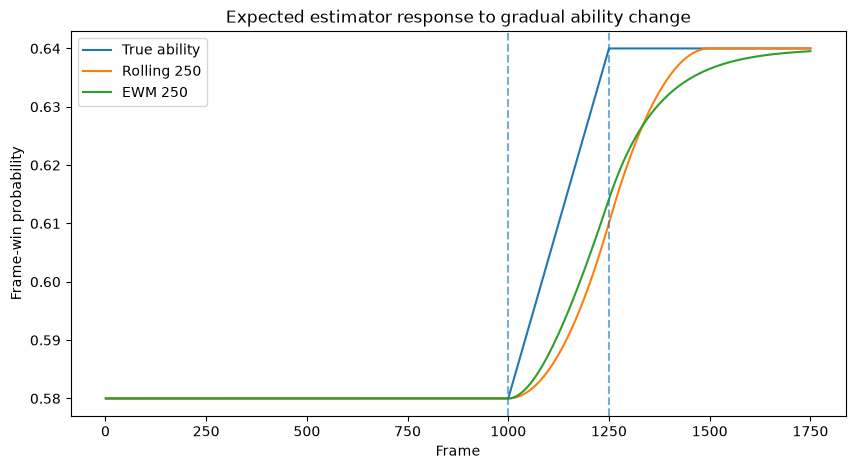

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(frames, true_p, label="True ability")
plt.plot(frames, expected_rolling_250, label="Rolling 250")
plt.plot(frames, expected_ewm_250, label="EWM 250")

plt.axvline(1000, linestyle="--", alpha=0.6)
plt.axvline(1250, linestyle="--", alpha=0.6)

plt.xlabel("Frame")
plt.ylabel("Frame-win probability")
plt.title("Expected estimator response to gradual ability change")
plt.legend()

plt.show()

## Gradual change turns estimation into a tracking problem

The plot shows a different problem from the abrupt-change studies.

When true ability rises continuously, neither estimator can simply wait for enough observations and then recover one new fixed level. For part of the career, the target itself is moving.

Both estimates therefore lag behind current ability.

The exponentially weighted estimator responds earlier because it concentrates more weight on recent frames. During the transition it generally stays closer to the rising true probability than the equally weighted 250-frame window.

But that advantage reverses once improvement stops.

After true ability reaches 64%, the rolling window progressively replaces every lower-probability transition frame and eventually consists entirely of 64% observations. The exponentially weighted estimator still retains a diminishing influence from older, weaker periods, so its final approach is slower.

So the distinction from Study 10 survives under gradual change:

> **A hard cutoff and gradual forgetting distribute the same broad amount of historical information differently, and that changes how they track a moving target.**

So far this result is completely free of sampling noise. The next step is to simulate actual frame outcomes and see how clearly this expected pattern survives in observed careers.

In [10]:
# Generate one observed win/loss result for every frame.
# A value of 1 is a frame win; 0 is a frame loss.
career_results = rng.binomial(
    n=1,
    p=true_p
)

len(career_results), np.unique(career_results)

(1750, array([0, 1]))

In [11]:
# Put the simulated frame results into a Series.
career_series = pd.Series(career_results)

# 250-frame rolling estimate.
career_rolling_250 = (
    career_series
    .rolling(window=250, min_periods=1)
    .mean()
)

# Exponentially weighted estimate with the same span as Study 10.
career_ewm_250 = (
    career_series
    .ewm(span=250, adjust=True)
    .mean()
)

career_rolling_250.iloc[-1], career_ewm_250.iloc[-1]

(np.float64(0.604), np.float64(0.5970151108290243))

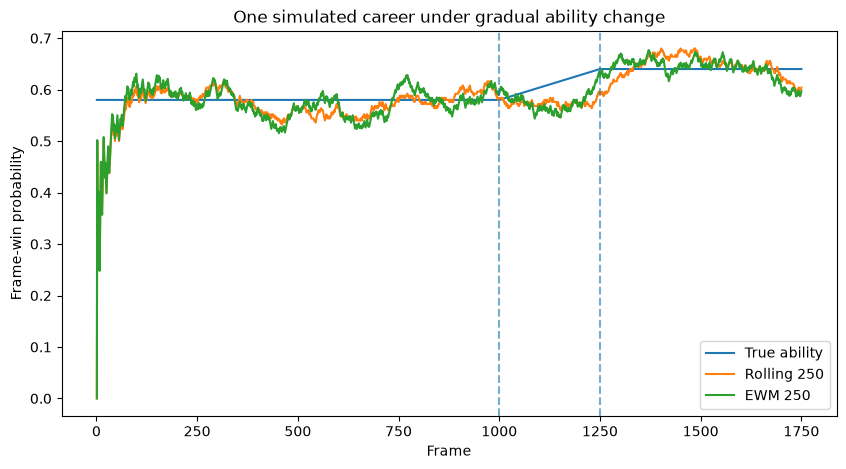

In [12]:
plt.figure(figsize=(10, 5))

# True underlying ability.
plt.plot(frames, true_p, label="True ability")

# Estimates from one simulated career.
plt.plot(frames, career_rolling_250, label="Rolling 250")
plt.plot(frames, career_ewm_250, label="EWM 250")

plt.axvline(1000, linestyle="--", alpha=0.6)
plt.axvline(1250, linestyle="--", alpha=0.6)

plt.xlabel("Frame")
plt.ylabel("Frame-win probability")
plt.title("One simulated career under gradual ability change")
plt.legend()

plt.show()

## One career is too noisy to reveal the underlying pattern reliably

The single simulated career shows the practical difficulty immediately.

Even though the true ability path is smooth and deterministic, the observed estimates move around substantially because frame results are binary wins and losses.

A particular career can therefore make an estimator appear to react early, late, or even in the wrong direction for a while simply through sampling variation.

This is especially visible early in the career, when the estimators have only a small number of observations available.

The noise-free calculation already told us what response we should expect on average. To check that the simulation reproduces that behaviour, we now need many independent careers following the same underlying probability path.

Averaging across repeated careers will reduce the random frame-to-frame noise and reveal the systematic estimator response.

In [13]:
# Simulate 10,000 careers following the same changing ability path.
n_careers = 10_000

repeated_results = (
    rng.random((n_careers, len(true_p))) < true_p
)

repeated_results.shape

(10000, 1750)

In [14]:
# Mean observed result at each frame across the 10,000 careers.
mean_frame_results = repeated_results.mean(axis=0)

mean_frame_series = pd.Series(mean_frame_results)

mean_rolling_250 = (
    mean_frame_series
    .rolling(window=250, min_periods=1)
    .mean()
)

mean_ewm_250 = (
    mean_frame_series
    .ewm(span=250, adjust=True)
    .mean()
)

mean_rolling_250.iloc[-1], mean_ewm_250.iloc[-1]

(np.float64(0.640258), np.float64(0.6396776588711748))

In [15]:
# Compare the simulated mean paths with the exact expected paths
# at the same checkpoints used earlier.
simulation_check = pd.DataFrame({
    "frame": check_frames,
    "true_p": [true_p[frame - 1] for frame in check_frames],

    "expected_rolling": [
        expected_rolling_250.iloc[frame - 1]
        for frame in check_frames
    ],
    "sim_mean_rolling": [
        mean_rolling_250.iloc[frame - 1]
        for frame in check_frames
    ],

    "expected_ewm": [
        expected_ewm_250.iloc[frame - 1]
        for frame in check_frames
    ],
    "sim_mean_ewm": [
        mean_ewm_250.iloc[frame - 1]
        for frame in check_frames
    ],
})

simulation_check.round(4)

,frame,true_p,expected_rolling,sim_mean_rolling,expected_ewm,sim_mean_ewm
0,1000,0.580,0.5800,0.5800,0.5800,0.5802
1,1050,0.592,0.5812,0.5813,0.5821,0.5823
2,1100,0.604,0.5848,0.5850,0.5875,0.5875
3,1150,0.616,0.5909,0.5911,0.5951,0.5952
4,1200,0.628,0.5993,0.5992,0.6042,0.6041
5,1250,0.640,0.6101,0.6097,0.6142,0.6136
6,1500,0.640,0.6400,0.6396,0.6365,0.6362
7,1750,0.640,0.6400,0.6403,0.6395,0.6397


## Repeated simulation reproduces the expected lag

Averaging across 10,000 careers removes most of the random variation visible in the single-career example.

The simulated mean estimates closely match the noise-free expected paths throughout the gradual transition.

At frame 1,250, when true ability has just reached 64%:

- the expected rolling estimate is 61.01%, compared with 60.97% in simulation;
- the expected exponentially weighted estimate is 61.42%, compared with 61.36% in simulation.

The small differences are ordinary Monte Carlo variation.

This confirms that the lag is a systematic consequence of the estimators' memory rather than an artefact of one particular simulated career.

The important feature is therefore not whether an estimate happens to be above or below the truth in one noisy sample. It is that, **on average, an estimator using historical evidence trails a target that is moving upward**.

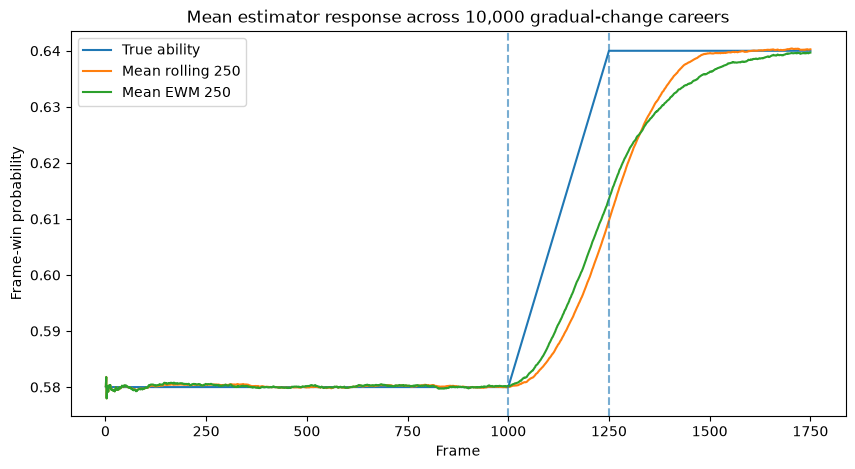

In [16]:
plt.figure(figsize=(10, 5))

# True ability and mean estimator paths across 10,000 careers.
plt.plot(frames, true_p, label="True ability")
plt.plot(frames, mean_rolling_250, label="Mean rolling 250")
plt.plot(frames, mean_ewm_250, label="Mean EWM 250")

plt.axvline(1000, linestyle="--", alpha=0.6)
plt.axvline(1250, linestyle="--", alpha=0.6)

plt.xlabel("Frame")
plt.ylabel("Frame-win probability")
plt.title("Mean estimator response across 10,000 gradual-change careers")
plt.legend()

plt.show()

In [17]:
# Systematic lag relative to the current true ability.
rolling_lag_pp = (true_p_series - expected_rolling_250) * 100
ewm_lag_pp = (true_p_series - expected_ewm_250) * 100

# Restrict the comparison to the 250-frame improvement period.
transition_slice = slice(1000, 1250)

max_lag = pd.DataFrame({
    "estimator": ["Rolling 250", "EWM 250"],
    "max_lag_pp": [
        rolling_lag_pp.iloc[transition_slice].max(),
        ewm_lag_pp.iloc[transition_slice].max(),
    ],
    "frame": [
        rolling_lag_pp.iloc[transition_slice].idxmax() + 1,
        ewm_lag_pp.iloc[transition_slice].idxmax() + 1,
    ],
})

max_lag.round(3)

,estimator,max_lag_pp,frame
0,Rolling 250,2.988,1250
1,EWM 250,2.583,1250


## The lag peaks when improvement stops

For this simple linear change, both estimators reach their largest systematic lag at frame 1,250 — the final frame of the improvement period.

At that point true ability has reached 64%, but the estimators are still summarising evidence gathered while the player was weaker:

- rolling 250 lags by 2.99 percentage points;
- EWM 250 lags by 2.58 percentage points.

The exponentially weighted estimator stays closer because recent, higher-probability frames receive more influence.

The important point is that the lag keeps growing while the target keeps moving. The estimators only begin to close the gap once true ability stops changing.

We can therefore separate the process into two phases:

1. **tracking:** while ability is changing, historical evidence causes the estimate to trail the current level;
2. **catch-up:** once ability becomes stable again, old lower-probability evidence gradually loses its influence.

In [18]:
# Check how quickly each estimator closes the gap after frame 1,250.
catchup_frames = [1250, 1300, 1350, 1400, 1500, 1750]

catchup_check = pd.DataFrame({
    "frame": catchup_frames,
    "rolling_lag_pp": [
        rolling_lag_pp.iloc[frame - 1]
        for frame in catchup_frames
    ],
    "ewm_lag_pp": [
        ewm_lag_pp.iloc[frame - 1]
        for frame in catchup_frames
    ],
})

catchup_check.round(3)

,frame,rolling_lag_pp,ewm_lag_pp
0,1250,2.988,2.583
1,1300,1.910,1.732
2,1350,1.073,1.161
3,1400,0.475,0.778
4,1500,0.000,0.350
5,1750,0.000,0.047


## Catch-up reverses the comparison

Once ability stops rising, both estimators begin closing the gap.

Initially the exponentially weighted estimator remains closer to the new 64% level:

- at frame 1,300, rolling lags by 1.91 percentage points;
- EWM lags by 1.73 points.

But the paths then cross.

By frame 1,350:

- rolling lags by 1.07 percentage points;
- EWM lags by 1.16 points.

The rolling window eventually catches up faster because lower-probability observations leave the window completely. By frame 1,500 its entire 250-frame memory comes from the stable 64% period, so its expected lag is exactly zero.

The exponentially weighted estimator has no equivalent cutoff. Its older evidence continues to fade rather than disappearing, leaving a small residual lag even 500 frames after the improvement finished.

So exponential weighting is again not simply a "faster" estimator.

It tracks the moving target more closely during much of the improvement, but the rolling window eventually overtakes it once the target becomes stationary.

In [19]:
# Find the first post-transition frame where rolling has no more lag than EWM.
post_transition = np.arange(1250, len(true_p))

crossover_index = post_transition[
    np.where(
        rolling_lag_pp.iloc[post_transition].to_numpy()
        <= ewm_lag_pp.iloc[post_transition].to_numpy()
    )[0][0]
]

crossover_frame = crossover_index + 1

pd.DataFrame({
    "frame": [crossover_frame],
    "rolling_lag_pp": [rolling_lag_pp.iloc[crossover_index]],
    "ewm_lag_pp": [ewm_lag_pp.iloc[crossover_index]],
}).round(3)

,frame,rolling_lag_pp,ewm_lag_pp
0,1334,1.315,1.319


## The crossover occurs 84 frames after improvement ends

The expected paths cross at frame 1,334, 84 frames after true ability reaches 64%.

At that point:

- rolling 250 lags by 1.315 percentage points;
- EWM 250 lags by 1.319 percentage points.

Before the crossover, exponential weighting remains closer to the current ability because it placed more emphasis on the stronger, more recent transition frames.

After the crossover, the rolling estimator becomes closer because its remaining lower-probability observations are being removed completely from the window.

This gives the response a clear sequence:

1. while ability is rising, EWM generally tracks it more closely;
2. shortly after improvement stops, EWM still retains that advantage;
3. 84 frames later, the rolling window overtakes it;
4. rolling eventually reaches zero expected lag, while EWM approaches zero gradually.

In [20]:
# Collect the main numerical results from the gradual-change experiment.
study11_summary = pd.DataFrame({
    "measure": [
        "True ability at transition end",
        "Rolling estimate at transition end",
        "EWM estimate at transition end",
        "Rolling maximum lag",
        "EWM maximum lag",
        "Post-transition crossover frame",
        "Rolling lag at frame 1500",
        "EWM lag at frame 1500",
    ],
    "value": [
        true_p[1249] * 100,
        expected_rolling_250.iloc[1249] * 100,
        expected_ewm_250.iloc[1249] * 100,
        rolling_lag_pp.iloc[1000:1250].max(),
        ewm_lag_pp.iloc[1000:1250].max(),
        crossover_frame,
        rolling_lag_pp.iloc[1499],
        ewm_lag_pp.iloc[1499],
    ],
})

study11_summary.round(3)

,measure,value
0,True ability at transition end,64.000
1,Rolling estimate at transition end,61.012
2,EWM estimate at transition end,61.417
3,Rolling maximum lag,2.988
4,EWM maximum lag,2.583
5,Post-transition crossover frame,1334.000
6,Rolling lag at frame 1500,0.000
7,EWM lag at frame 1500,0.350


## Study 11 conclusion

Replacing the abrupt 58% → 64% jump with a gradual 250-frame improvement changes the estimation problem in an important way.

While ability is rising, the target itself is moving. Both estimators therefore lag behind current ability because they necessarily use evidence generated when the player was weaker.

At the end of the transition:

- true ability is 64.00%;
- rolling 250 estimates 61.01%;
- EWM 250 estimates 61.42%.

The maximum expected lag occurs at that same point:

- rolling 250: 2.99 percentage points;
- EWM 250: 2.58 percentage points.

Exponential weighting tracks the improvement more closely because recent frames receive greater weight. But once ability stops changing, the comparison reverses.

The rolling estimator eventually removes every lower-probability observation from its window. It overtakes the EWM at frame 1,334, 84 frames after the transition ends, and reaches zero expected lag by frame 1,500.

The EWM retains a fading influence from older evidence, leaving a small 0.35 percentage-point lag at frame 1,500.

The central result is:

> **When the underlying ability is changing, estimation becomes a tracking problem. Historical evidence creates systematic lag even when the estimator itself is behaving exactly as designed.**

Study 10 showed that how we forget history changes the response to a sudden change.

Study 11 adds another layer:

> **The shape of the underlying change matters too. A moving target can make even a sensible estimator look stale because the past and present no longer describe the same ability level.**

This study does not establish which estimator is best. It only shows how the same estimators behave when the thing being estimated changes gradually rather than instantaneously.

## Scope and limitations

Study 11 deliberately changes only one feature of the earlier setup: the abrupt ability jump is replaced by one simple linear improvement from 58% to 64% over 250 frames.

The study still assumes:

- independent frame outcomes conditional on the current true probability;
- no momentum or serial dependence;
- no parameter uncertainty;
- no opponent effects;
- no match-format effects;
- no injuries, confidence effects, tactical changes, or other real-player mechanisms.

The 250-frame transition is illustrative rather than estimated from data.

We also do not compare alternative transition lengths or shapes. A slower improvement, faster improvement, plateau, decline, or non-linear change could produce different amounts and patterns of lag.

The purpose here is narrower:

> **to isolate what happens when the target itself moves gradually while the estimator continues to rely on historical evidence.**

The next logical extensions could introduce richer change paths or methods designed specifically to detect and adapt to changing ability, but those are separate questions and should not be folded into this study.